[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FranQuant/llm-regime-allocator/blob/main/notebooks/nb03_memory_and_blinding.ipynb)

In [1]:
# Setup. On Colab this fetches the repo (data, results, replayable LLM cache); locally it does nothing.
# No API keys or paid calls are needed anywhere in this notebook.
import os, subprocess, sys
if 'google.colab' in sys.modules:
    REPO = '/content/llm-regime-allocator'
    if not os.path.exists(REPO):
        subprocess.run(['git', 'clone', '-q', '--depth', '1', 'https://github.com/FranQuant/llm-regime-allocator.git', REPO], check=True)
    sys.path.insert(0, f'{REPO}/src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from lra import viz
viz.apply_style()

# nb03 — Can we trust it? Memory and blinding

**Question.** Sonnet was trained on text that describes 2008–2026. nb02's result could come from reading the snapshot, or from recognising the month and recalling what came next. This notebook measures the memory, removes most of it, and runs the test again. Every answer is replayed from the committed cache; no API calls.

## Setup

Same model, same 222 months, five prompt variants:

| Variant | The model sees |
|---|---|
| raw | the nb02 snapshot: no date, no tickers |
| raw + date | the same snapshot plus the as-of date |
| date only | the date and no data |
| date probe | the snapshot, and the question *which month is this?* |
| blinded | every figure replaced by a trailing z-score (below) |

**Blinding.** Each figure $x_t$ becomes
$$z_t=\frac{x_t-\bar x_{t-35:t}}{s_{t-35:t}},$$
the distance from its own mean $\bar x$ over the last 36 months in units of its standard deviation $s$ (trailing data only; at least 12 months), rounded to 0.5 and capped at ±3. Levels and percentages disappear; direction and extremes remain.

**Intervals.** 95% moving-block bootstrap (6-month blocks) of the paired monthly difference.

In [2]:
from lra import evaluation as ev
reg, fair = viz.read('results/baselines/regimes.csv'), viz.read('results/baselines/regimes_fair.csv')
y = reg['realised_forward'].dropna()
son = {v: viz.read(f'results/llm/claude_sonnet/{v}_run0.csv') for v in
       ('anonymized', 'dated', 'date_only', 'blinded', 'date_probe', 'date_probe_blinded')}
cols = lambda df, p: df[[f'{p}_{k}' for k in viz.REGIMES]].set_axis(viz.REGIMES, axis=1)
base = ev.brier_per_obs(ev.uniform(y.index), y)
def gap(p, idx=y.index):
    d = ev.brier_per_obs(p[viz.REGIMES], y.loc[idx]) - base.loc[idx]
    return d.mean(), *ev.block_bootstrap_ci(d)

## 1. Telling it the date helps — a sign of memory

In [3]:
rows = {v: ev.score(son[k][viz.REGIMES], y) for v, k in
        [('date only', 'date_only'), ('raw', 'anonymized'), ('raw + date', 'dated')]}
d = ev.brier_per_obs(son['dated'][viz.REGIMES], y) - ev.brier_per_obs(son['anonymized'][viz.REGIMES], y)
print('raw + date minus raw, Brier: {:+.3f}  (95% CI {:+.3f} to {:+.3f})'.format(d.mean(), *ev.block_bootstrap_ci(d)))
viz.fmt(pd.DataFrame(rows).T[['hit_rate', 'brier']], pct=['hit_rate'])

raw + date minus raw, Brier: -0.051  (95% CI -0.070 to -0.036)


,hit_rate,brier
date only,22%,0.747
raw,37%,0.702
raw + date,47%,0.651


**Reading.** **Control:** with the date and no data, Sonnet declines to guess (Brier 0.747, about uniform). **Key finding:** adding the date to the data improves Brier by 0.051, with an interval well clear of zero. Where the date flips the top call (54 months), the dated call is right 28 times and the raw call 6 times. Data plus date beats data alone: the model holds outcome knowledge it uses once it knows where it is.

## 2. It can find the date anyway

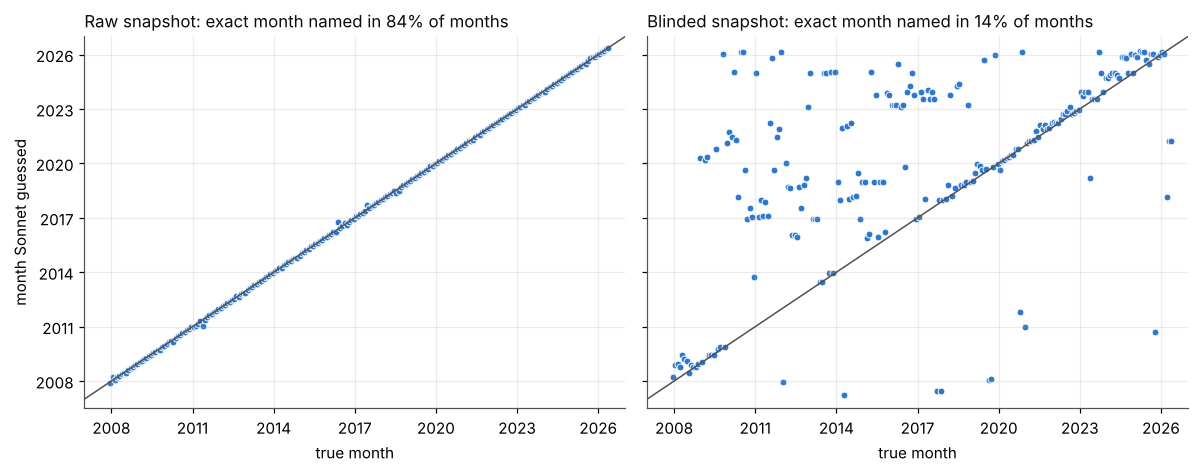

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for ax, k, title in zip(axes, ['date_probe', 'date_probe_blinded'], ['Raw snapshot', 'Blinded snapshot']):
    p = son[k]; t = p.index.year + (p.index.month - 0.5) / 12
    g = p['guess_year'] + (p['guess_month'] - 0.5) / 12
    ax.plot([2007, 2027], [2007, 2027], color=viz.MUTED, lw=1)
    ax.scatter(t, g, s=20, color=viz.MODEL_COLORS['claude_sonnet'], edgecolor='white', lw=0.6)
    exact = (p['error_months'] == 0).mean()
    ax.set_title(f'{title}: exact month named in {exact:.0%} of months')
    ax.set_xlabel('true month'); ax.set_xlim(2007, 2027); ax.set_ylim(2006.5, 2027)
    ax.set_xticks(range(2008, 2027, 3)); ax.set_yticks(range(2008, 2027, 3))
axes[0].set_ylabel('month Sonnet guessed'); plt.tight_layout(); plt.show()

**Reading.** **Key finding:** removing the date did not anonymise anything. From levels such as the policy rate, the 10-year yield and unemployment, Sonnet names the exact month of the raw snapshot 84% of the time (left: points on the diagonal). The raw result of nb02 is therefore not out-of-sample. Blinded, the exact-month rate falls to 14% (right). The 2008 crisis and most months since 2019 (COVID, the 2022 inflation) stay recognisable; 2010–2018 scatters across the whole range.

## 3. The same month, raw and blinded

In [5]:
from lra.llm.blind import blind_features
from lra.llm.prompts import render_data, render_blinded
feat = viz.read('results/baselines/features.csv'); d0 = pd.Timestamp('2013-05-31')
keep = ('indicator |', 'Unemployment rate', '10-year Treasury yield', 'Headline CPI', 'Gold')
show = lambda text: '\n'.join(l for l in text.splitlines() if l.startswith(keep))
print('RAW\n' + show(render_data(feat.loc[d0])) + '\n\nBLINDED\n' + show(render_blinded(blind_features(feat).loc[d0])))

RAW
indicator | units | latest | 3m chg | 12m chg | z
Unemployment rate | % | +7.50 | -0.40 | -0.60 | -1.69
Headline CPI | YoY % | +1.11 | -0.47 | -1.16 | -1.23
10-year Treasury yield | % | +2.13 | +0.24 | +0.54 | -0.29
Gold | -5.1% | -12.1% | -19.6% | -11.3% | +20.1% | -22.9%

BLINDED
indicator | level | 3m change | 12m change
Unemployment rate | -1.5 | -1.0 | +0.0
Headline CPI | -1.0 | -0.5 | -1.0
10-year Treasury yield | -0.5 | +1.0 | +2.0
Gold | -1.0 | -2.0 | -2.5 | -1.5 | +0.5 | -2.5


**Reading.** May 2013 raw carries fingerprints (a 7.5% unemployment rate, a 2% ten-year yield, CPI near 1%); blinded, the same lines only say that unemployment is low against its recent past, that yields are near their 3-year average and that gold has fallen sharply.

## 4. What survives blinding

Every forecaster against uniform, with intervals; ML now also sees the blinded snapshot, so it has exactly the information the LLM has.

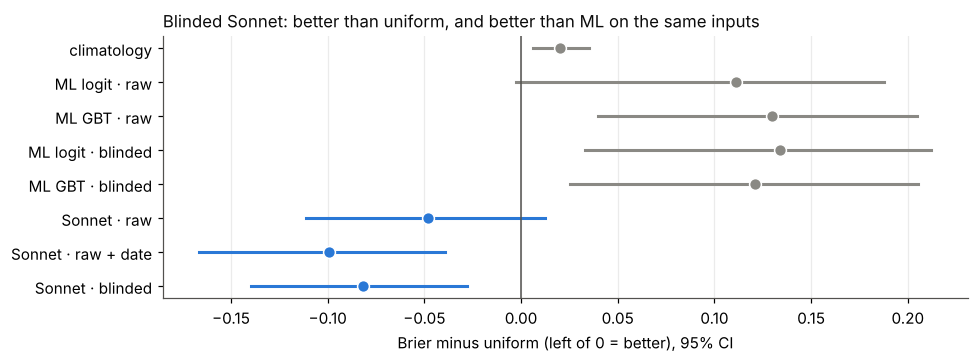

,brier,diff,lo,hi
climatology,0.770,0.020,0.006,0.035
ML logit · raw,0.861,0.111,-0.003,0.187
ML GBT · raw,0.880,0.130,0.040,0.205
ML logit · blinded,0.884,0.134,0.033,0.212
ML GBT · blinded,0.871,0.121,0.025,0.205
Sonnet · raw,0.702,-0.048,-0.111,0.013
Sonnet · raw + date,0.651,-0.099,-0.166,-0.040
Sonnet · blinded,0.668,-0.082,-0.139,-0.028


In [6]:
fc = {'climatology': cols(fair, 'climatology'), 'ML logit · raw': cols(reg, 'logit'),
      'ML GBT · raw': cols(reg, 'gbt'), 'ML logit · blinded': cols(fair, 'logit_blinded'),
      'ML GBT · blinded': cols(fair, 'gbt_blinded'), 'Sonnet · raw': son['anonymized'],
      'Sonnet · raw + date': son['dated'], 'Sonnet · blinded': son['blinded']}
g = pd.DataFrame({k: gap(p) for k, p in fc.items()}, index=['diff', 'lo', 'hi']).T
g['brier'] = g['diff'] + 0.75
fig, ax = plt.subplots(figsize=(9, 3.4))
c = [viz.MODEL_COLORS['claude_sonnet'] if k.startswith('Sonnet') else viz.GREYS['ml'] for k in g.index]
viz.ci_forest(ax, g['diff'], g.lo, g.hi, g.index, c, xlabel='Brier minus uniform (left of 0 = better), 95% CI')
ax.set_title('Blinded Sonnet: better than uniform, and better than ML on the same inputs'); plt.tight_layout(); plt.show()
viz.fmt(g[['brier', 'diff', 'lo', 'hi']])

**Reading.** **Key finding:** on the blinded snapshot Sonnet scores 0.668, better than on raw levels and better than uniform with an interval clear of zero, while ML given the same blinded inputs scores 0.871–0.884. Blinding removed most of the date signal and none of the forecasting skill.

In [7]:
err = son['date_probe_blinded']['error_months'].abs().reindex(y.index)
groups = {'cannot date (> 12 months off)': y.index[err > 12], 'can date (≤ 12 months)': y.index[err <= 12]}
t = pd.DataFrame({g: [len(i), *gap(son['blinded'], i)] for g, i in groups.items()},
                 index=['months', 'Sonnet − uniform', 'lo', 'hi']).T
viz.fmt(t, d0=['months'])

,months,Sonnet − uniform,lo,hi
cannot date (> 12 months off),109,-0.051,-0.120,0.030
can date (≤ 12 months),108,-0.113,-0.185,-0.053


**Reading.** In the 109 months Sonnet cannot date from the blinded snapshot, its edge over uniform is smaller (−0.051) and its interval touches zero; in the months it can date the edge is larger. Those undatable months are mostly 2008–2019, so this split mixes memory with period (section 6).

## 5. The portfolio after blinding

In [8]:
met = pd.read_csv(viz.RESULTS / 'phase5' / 'metrics.csv'); met = met[met.cost_bps == 2.5].set_index('strategy')
S = {'raw · top regime (nb02)': 'playbook_top__llm_sonnet_raw', 'blinded · top regime': 'playbook_top__llm_sonnet_blinded',
     'blinded · blend': 'playbook__llm_sonnet_blinded', '60/40': 'sixty_forty', 'uniform control': 'playbook__uniform'}
from lra.evaluation import monthly_excess, sharpe_diff_ci
px = pd.read_csv(viz.DATA / 'etf_prices.csv', parse_dates=['date'], index_col='date')
mex = monthly_excess(viz.daily(), px['BIL'].pct_change())
for a, b, lab in [(S['raw · top regime (nb02)'], S['blinded · top regime'], 'raw minus blinded (top regime)'),
                  (S['blinded · blend'], S['uniform control'], 'blinded blend minus control')]:
    print('{:32s} Sharpe {:+.2f}  (95% CI {:+.2f} to {:+.2f})'.format(lab, *sharpe_diff_ci(mex[a], mex[b])))
tab = met.loc[list(S.values()), ['ann_return', 'ann_vol', 'sharpe', 'max_drawdown', 'turnover_per_year']]
viz.fmt(tab.set_axis(list(S), axis=0), pct1=['ann_return', 'ann_vol'], pct=['max_drawdown'], d2=['sharpe', 'turnover_per_year'])

raw minus blinded (top regime)   Sharpe +0.11  (95% CI -0.11 to +0.34)
blinded blend minus control      Sharpe +0.14  (95% CI -0.03 to +0.31)


,ann_return,ann_vol,sharpe,max_drawdown,turnover_per_year
raw · top regime (nb02),8.1%,8.3%,0.83,-14%,2.23
blinded · top regime,7.5%,8.4%,0.75,-15%,2.20
blinded · blend,6.8%,7.3%,0.76,-16%,0.87
60/40,8.3%,11.1%,0.66,-32%,0.11
uniform control,6.1%,8.1%,0.61,-26%,0.13


**Reading.** Blinding lowers the top-regime Sharpe from 0.83 to 0.75 (+0.11 on the paired monthly measure, interval −0.11 to +0.34): a rough price of memory, not a significant one. The blinded blend keeps a −16% drawdown and Sharpe 0.76 against 0.61 for the control; that +0.14 still sits inside the noise.

## 6. Robustness

Added after an external adversarial review; each check is one table.

**(a) Is "cannot date" just a period split?** Gain over uniform by era and datability, then the datable effect with year fixed effects:

In [9]:
viz.fmt(pd.read_csv(viz.RESULTS / 'h1' / 'date_probe_era.csv').replace({'2007-2019': '2007–2019', '2020-2026': '2020–2026'})).hide(axis='index')

era,bucket,n,brier_minus_uniform,ci_lo,ci_hi
2007–2019,can date,47,-0.139,–,–
2007–2019,cannot date,98,-0.047,–,–
2020–2026,can date,61,-0.094,–,–
2020–2026,cannot date,11,-0.085,–,–
"all, year fixed effects",datable minus cannot-date,217,0.037,-0.076,0.134


**Reading.** Comparing months within the same year, the datable months show no reliable extra gain (+0.037, interval −0.08 to +0.13): the split cannot separate memory from period.

**(b) Outcome vintage.** Scoring each month with the first data release that makes its regime knowable changes 33 of 217 labels:

In [10]:
sc = pd.read_csv(viz.RESULTS / 'h1' / 'scores.csv')
keep = ['uniform', 'climatology', 'ml_logit', 'ml_logit_blinded', 'claude_sonnet:anonymized',
        'claude_sonnet:dated', 'claude_sonnet:blinded']
viz.fmt(sc[sc.forecaster.isin(keep) & sc.window.isin(['full', 'first-release labels'])]
        .pivot(index='forecaster', columns='window', values='brier').loc[keep])

window,first-release labels,full
forecaster,,
uniform,0.750,0.750
climatology,0.765,0.770
ml_logit,0.822,0.861
ml_logit_blinded,0.854,0.884
claude_sonnet:anonymized,0.669,0.702
claude_sonnet:dated,0.627,0.651
claude_sonnet:blinded,0.646,0.668


**Reading.** Every forecaster scores slightly better on first-release labels; no ranking changes.

**(c) CFNAI before 2011-05 uses revised values** (its ALFRED vintages start then). Sonnet was re-asked the 41 affected months without the CFNAI line:

In [11]:
viz.fmt(pd.read_csv(viz.RESULTS / 'h1' / 'nocfnai_check.csv'), pct=['hit_rate']).hide(axis='index')

forecaster,n,hit_rate,brier,log_loss,ci_lo,ci_hi
"blinded, 2007-12..2011-04",41,49%,0.599,1.094,–,–
"blinded without CFNAI, 2007-12..2011-04",41,46%,0.622,1.145,–,–
"uniform, 2007-12..2011-04",41,17%,0.750,1.386,–,–
"blinded, full sample",217,46%,0.668,1.244,–,–
"blinded with CFNAI-free months spliced in, full sample",217,45%,0.672,1.254,–,–
difference: without minus with CFNAI (Brier),41,–,0.023,–,0.003,0.046


**Reading.** Without CFNAI Sonnet is slightly worse in those months and still far better than uniform; splicing them into the full sample moves its Brier from 0.668 to 0.672.

**(d) Black-Litterman instead of a playbook.** Two designs (Setup of `scripts/run_regime_bl.py`): **5a**, fixed in advance, turns probabilities into return views $Q=\sum_k p_{t,k}\mu_k$ from shrunk regime-conditional means; **5b**, added after 5a failed, uses the returns implied by the blended playbook, $Q=\delta\,\Sigma\,(p_t\cdot w^{(k)})$. View confidence falls with the entropy of the forecast, $\kappa=\max(1-H(p)/\ln 4,\,0.05)$, so a hedged forecast gives weak views.

In [12]:
rows = ['llm_sonnet_blinded', 'ml_gbt', 'uniform', 'oracle']
bl = pd.DataFrame({'5a (pre-registered)': met.loc[[f'bl_regime__{r}' for r in rows], 'sharpe'].values,
                   '5b (post-hoc)': met.loc[[f'bl_playbook__{r}' for r in rows], 'sharpe'].values},
                  index=['Sonnet blinded', 'ML GBT raw', 'uniform control', 'oracle'])
bl.loc['BL without views'] = met.loc['bl_equilibrium', 'sharpe']
viz.fmt(bl, d2=list(bl.columns))

,5a (pre-registered),5b (post-hoc)
Sonnet blinded,0.52,0.65
ML GBT raw,0.42,0.65
uniform control,0.53,0.58
oracle,0.51,0.86
BL without views,0.57,0.57


**Reading.** Design 5a fails even with perfect foresight (oracle 0.51, below BL without views at 0.57): noisy regime-conditional returns push the optimiser into concentrated bets. Design 5b works for the oracle (0.86) and gives blinded Sonnet a small, non-significant improvement over the control (0.65 against 0.58), because its hedged probabilities produce weak views.

**(e) Costs.** One-way turnover is 0.1–2.8 times a year, so 10 bps instead of 2.5 lowers any Sharpe here by a few hundredths and changes no ranking (`results/phase5/metrics.csv`, cost columns).

## What we can and cannot claim

- **Memory is real.** From a date-free raw snapshot Sonnet names the exact month 84% of the time, and telling it the date improves its forecasts. Raw-snapshot backtests of LLM forecasters are not out-of-sample.
- **Blinding removes most of the date signal and keeps the forecast:** Brier 0.668, better than uniform and than ML on identical inputs.
- **Portfolios keep most of the nb02 picture after blinding** (Sharpe 0.75–0.76, drawdown about −15%), still not significant.
- **Not shown:** that the blinded edge is skill rather than memory. The blinding was designed after the raw snapshot failed, on the same history, and the months Sonnet still dates are the recent ones.

## Next

nb04 asks whether this holds for other model families, and whether blinding hides the date from them too.